# Guía práctica de Minería de Datos
## Alerta temprana de abandono estudiantil

**Entorno:** Google Colab  
**Tipo de datos:** base simulada propia inspirada en OULAD  
**Alcance de esta etapa:** generación de datos, exploración, limpieza, transformación, clustering, comparación de modelos, evaluación y exportación del modelo final.

> La API, la aplicación que consumirá la API y los documentos finales se desarrollarán después. Este cuaderno termina con un modelo portátil y sus metadatos.

## 1. Definición del problema

### Problema

Una institución de educación virtual necesita identificar, al finalizar los primeros 30 días de estudio, qué estudiantes presentan riesgo de abandonar posteriormente. La detección temprana permitiría priorizar tutorías, recordatorios y acciones de acompañamiento antes de que el retiro ocurra.

### Pregunta de investigación

**¿En qué medida la actividad académica registrada durante los primeros 30 días permite predecir el abandono posterior de los estudiantes?**

### Objetivo general

Desarrollar y evaluar un modelo de minería de datos que estime el riesgo de abandono posterior al día 30 y pueda ser integrado posteriormente en una API.

### Objetivos específicos

1. Explorar la estructura, calidad y distribución de una base simulada de estudiantes.
2. Limpiar y transformar los datos mediante tratamiento de nulos, duplicados, valores atípicos y codificación de variables.
3. Generar indicadores derivados de participación y cumplimiento académico.
4. Identificar perfiles estudiantiles mediante PCA y K-Means.
5. Comparar tres clasificadores mediante validación cruzada y métricas de clasificación.
6. Exportar el modelo seleccionado con el preprocesamiento y los metadatos requeridos por una futura API.

### Delimitación

- Unidad de análisis: un estudiante único.
- Contexto: educación virtual simulada.
- Periodo observado: días 0 a 29 del curso.
- Variable objetivo: `abandono`, donde 1 indica retiro posterior al día 30 y 0 permanencia.
- Uso: prototipo académico; no debe emplearse para sancionar ni excluir estudiantes.

### Elevator pitch

> Las instituciones virtuales generan información sobre acceso, tareas, calificaciones y participación, pero estos datos pierden valor cuando el abandono se detecta demasiado tarde. Este proyecto construye una base simulada y reproducible de estudiantes, inspirada en variables del conjunto OULAD, para identificar señales observables durante los primeros 30 días. Se analizarán la calidad y distribución de los datos, se crearán indicadores de actividad y cumplimiento, y se aplicarán PCA y K-Means para describir perfiles de participación. Posteriormente se compararán regresión logística, árbol de decisión y bosque aleatorio mediante validación cruzada, F1, recall y ROC-AUC. El modelo con mejor desempeño se exportará como una tubería completa, lista para integrarse en una API de alerta temprana. Su resultado servirá únicamente como apoyo para orientar acompañamiento académico y no como una decisión automática.

## 2. Fuente y justificación

La base se genera de forma simulada y reproducible con 2.000 estudiantes únicos. Su estructura toma como referencia variables demográficas, académicas y de interacción presentes en OULAD, conjunto que integra información estudiantil y actividad en un entorno virtual de aprendizaje (Kuzilek et al., 2017).

La comparación de varios clasificadores es pertinente porque los algoritmos supervisados pueden presentar desempeños distintos ante el desbalance de clases y las características de cada contexto educativo (Villar & de Andrade, 2024).

Se emplean únicamente variables disponibles durante los primeros 30 días y la etiqueta representa un evento posterior. De esta forma se evita utilizar información futura para construir la predicción.

**Fuentes verificables**

- UCI: https://archive.ics.uci.edu/dataset/349/open+university+learning+analytics+dataset
- Artículo descriptor: https://doi.org/10.1038/sdata.2017.171
- Estudio reciente: https://doi.org/10.1007/s44163-023-00079-z

In [ ]:
from pathlib import Path
try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj.to_string() if hasattr(obj, 'to_string') else obj)
import importlib.metadata as package_metadata
import json
import os
import platform
import zipfile

# Evita avisos de detección de núcleos en algunos entornos administrados.
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '2')

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, silhouette_score, davies_bouldin_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.tree import DecisionTreeClassifier

SEMILLA = 42
N_ESTUDIANTES = 2_000
VENTANA_DIAS = 30

RUTA_BASE = Path('/content') if Path('/content').exists() else Path.cwd()
RUTA_TRABAJO = RUTA_BASE / 'mineria_datos_modelo_final'
RUTA_FIGURAS = RUTA_TRABAJO / 'figuras'
RUTA_EXPORTACION = RUTA_TRABAJO / 'modelo_exportado'
for ruta in [RUTA_TRABAJO, RUTA_FIGURAS, RUTA_EXPORTACION]:
    ruta.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='colorblind')
pd.set_option('display.max_columns', 30)

print('Python:', platform.python_version())
print('pandas:', pd.__version__)
import sklearn
print('scikit-learn:', sklearn.__version__)
print('Semilla reproducible:', SEMILLA)

Python: 3.13.15
pandas: 2.2.3
scikit-learn: 1.6.1
Semilla reproducible: 42


# Fase 1. Construcción de la base propia

La simulación utiliza una semilla fija para que cualquier persona obtenga exactamente los mismos registros. Todas las variables predictoras representan información disponible hasta el día 29. La etiqueta `abandono` se genera como un evento posterior al día 30.

Para demostrar el proceso de limpieza se incorporan de manera controlada valores nulos, diez valores extremos plausibles en clics y veinte filas duplicadas. Estas alteraciones se documentan y no se presentan como observaciones reales.

In [ ]:
rng = np.random.default_rng(SEMILLA)
n = N_ESTUDIANTES

edad = np.clip(np.rint(rng.normal(29, 8, n)), 18, 55).astype(int)
modalidad = rng.choice(['Virtual', 'Semipresencial'], n, p=[0.72, 0.28])
educacion = rng.choice(
    ['Bachillerato', 'Técnico', 'Universitario'],
    n,
    p=[0.55, 0.28, 0.17],
).astype(object)
intentos = np.clip(rng.poisson(0.35, n), 0, 3)
creditos = rng.choice([30, 60, 90, 120], n, p=[0.32, 0.46, 0.17, 0.05])
dias_registro = np.clip(np.rint(rng.normal(35, 22, n)), -20, 100).astype(float)

nivel_actividad = np.clip(
    rng.beta(2.0, 2.5, n)
    + 0.08 * (modalidad == 'Semipresencial')
    - 0.05 * intentos,
    0,
    1,
)
dias_activos = np.clip(np.rint(nivel_actividad * VENTANA_DIAS), 0, VENTANA_DIAS).astype(int)
clicks = np.rint(
    np.maximum(0, dias_activos * rng.gamma(3.5, 10, n) + rng.normal(20, 35, n))
).astype(int)

tareas_asignadas = rng.integers(4, 9, n)
probabilidad_entrega = np.clip(
    0.18
    + 0.72 * (dias_activos / VENTANA_DIAS)
    - 0.07 * intentos
    + 0.05 * (modalidad == 'Semipresencial'),
    0.03,
    0.97,
)
tareas_entregadas = rng.binomial(tareas_asignadas, probabilidad_entrega)
tasa_entrega_original = tareas_entregadas / tareas_asignadas

nota = np.where(
    tareas_entregadas > 0,
    np.clip(
        rng.normal(
            47 + 38 * tasa_entrega_original + 0.55 * dias_activos - 3 * intentos,
            12,
            n,
        ),
        0,
        100,
    ),
    np.nan,
)
solicito_soporte = rng.binomial(
    1,
    np.clip(0.08 + 0.18 * intentos + 0.18 * (dias_activos < 7), 0.02, 0.75),
)

# El riesgo usa solo información temprana; el ruido evita una relación artificial perfecta.
nota_para_simulacion = np.nan_to_num(nota, nan=35) / 100
logit_riesgo = (
    -4.5
    + 2.6 * (1 - dias_activos / VENTANA_DIAS)
    + 2.2 * (1 - tasa_entrega_original)
    + 1.7 * (1 - nota_para_simulacion)
    + 0.50 * intentos
    + 0.35 * (modalidad == 'Virtual')
    + 0.25 * (creditos >= 90)
    - 0.25 * solicito_soporte
    + rng.normal(0, 0.30, n)
)
probabilidad_abandono = 1 / (1 + np.exp(-logit_riesgo))
abandono = rng.binomial(1, probabilidad_abandono)

# Nulos y atípicos controlados para practicar limpieza con total transparencia.
educacion[rng.choice(n, 40, replace=False)] = None
dias_registro[rng.choice(n, 20, replace=False)] = np.nan
indices_con_nota = np.where(~np.isnan(nota))[0]
nota[rng.choice(indices_con_nota, 70, replace=False)] = np.nan
clicks[rng.choice(n, 10, replace=False)] *= 4

datos_originales = pd.DataFrame({
    'id_estudiante': np.arange(1, n + 1),
    'edad': edad,
    'modalidad': modalidad,
    'nivel_educativo_previo': educacion,
    'intentos_previos': intentos,
    'creditos_matriculados': creditos,
    'dias_anticipacion_registro': dias_registro,
    'clicks_30_dias': clicks,
    'dias_activos_30': dias_activos,
    'tareas_asignadas_30': tareas_asignadas,
    'tareas_entregadas_30': tareas_entregadas,
    'nota_promedio_30': nota,
    'solicito_soporte': solicito_soporte,
    'abandono': abandono,
})

# Se agregan 20 copias exactas para cuantificar claramente su eliminación.
datos_crudos = pd.concat(
    [datos_originales, datos_originales.sample(20, random_state=SEMILLA)],
    ignore_index=True,
)

RUTA_CSV_CRUDO = RUTA_TRABAJO / 'base_estudiantes_simulada_cruda.csv'
datos_crudos.to_csv(RUTA_CSV_CRUDO, index=False)

print('Base creada:', datos_crudos.shape)
print('Registros únicos previstos:', N_ESTUDIANTES)
print('Variable objetivo: abandono posterior al día 30')
display(datos_crudos.head())

Base creada: (2020, 14)
Registros únicos previstos: 2000
Variable objetivo: abandono posterior al día 30


,id_estudiante,edad,modalidad,nivel_educativo_previo,intentos_previos,creditos_matriculados,dias_anticipacion_registro,clicks_30_dias,dias_activos_30,tareas_asignadas_30,tareas_entregadas_30,nota_promedio_30,solicito_soporte,abandono
0,1,31,Virtual,Bachillerato,0,30,29.0,65,11,7,2,40.123948,0,1
1,2,21,Virtual,Bachillerato,0,60,41.0,323,18,7,6,89.144694,0,0
2,3,35,Virtual,Bachillerato,0,30,46.0,127,15,5,4,71.156981,0,0
3,4,37,Virtual,Bachillerato,0,90,60.0,262,6,5,2,76.189378,0,0
4,5,18,Virtual,Técnico,0,60,42.0,789,19,4,3,92.605931,1,0


In [ ]:
diccionario_variables = pd.DataFrame([
    ['id_estudiante', 'Identificador', 'Código único; no entra al modelo'],
    ['edad', 'Numérica', 'Edad en años'],
    ['modalidad', 'Categórica', 'Modalidad de estudio'],
    ['nivel_educativo_previo', 'Categórica', 'Nivel educativo previo'],
    ['intentos_previos', 'Numérica discreta', 'Intentos académicos anteriores'],
    ['creditos_matriculados', 'Numérica discreta', 'Créditos matriculados'],
    ['dias_anticipacion_registro', 'Numérica', 'Días de anticipación; negativo significa registro tardío'],
    ['clicks_30_dias', 'Numérica', 'Clics registrados entre los días 0 y 29'],
    ['dias_activos_30', 'Numérica discreta', 'Días con actividad entre 0 y 29'],
    ['tareas_asignadas_30', 'Numérica discreta', 'Tareas asignadas durante la ventana'],
    ['tareas_entregadas_30', 'Numérica discreta', 'Tareas entregadas durante la ventana'],
    ['nota_promedio_30', 'Numérica', 'Promedio temprano; nulo si no existe información'],
    ['solicito_soporte', 'Binaria', '1 si solicitó apoyo académico'],
    ['abandono', 'Binaria objetivo', '1 si abandona después del día 30'],
], columns=['variable', 'tipo', 'descripcion'])

display(diccionario_variables)

,variable,tipo,descripcion
0,id_estudiante,Identificador,Código único; no entra al modelo
1,edad,Numérica,Edad en años
2,modalidad,Categórica,Modalidad de estudio
3,nivel_educativo_previo,Categórica,Nivel educativo previo
4,intentos_previos,Numérica discreta,Intentos académicos anteriores
5,creditos_matriculados,Numérica discreta,Créditos matriculados
6,dias_anticipacion_registro,Numérica,Días de anticipación; negativo significa regis...
7,clicks_30_dias,Numérica,Clics registrados entre los días 0 y 29
8,dias_activos_30,Numérica discreta,Días con actividad entre 0 y 29
9,tareas_asignadas_30,Numérica discreta,Tareas asignadas durante la ventana


# Fase 2. Calidad, limpieza y exploración

Se reportan cantidad y porcentaje de nulos por variable. Para resolver la observación sobre `drop_duplicates`, también se muestran los registros antes y después, el número eliminado y su porcentaje.

In [ ]:
calidad_antes = pd.DataFrame({
    'tipo': datos_crudos.dtypes.astype(str),
    'nulos': datos_crudos.isna().sum(),
    'porcentaje_nulos': (datos_crudos.isna().mean() * 100).round(2),
    'valores_unicos': datos_crudos.nunique(dropna=False),
}).sort_values('porcentaje_nulos', ascending=False)

filas_antes = len(datos_crudos)
duplicados_antes = int(datos_crudos.duplicated().sum())
porcentaje_duplicados_antes = duplicados_antes / filas_antes * 100

datos = datos_crudos.drop_duplicates().copy()
filas_despues = len(datos)
duplicados_despues = int(datos.duplicated().sum())

resumen_duplicados = pd.DataFrame([{
    'filas_antes': filas_antes,
    'duplicados_detectados': duplicados_antes,
    'porcentaje_duplicados': round(porcentaje_duplicados_antes, 2),
    'filas_despues': filas_despues,
    'duplicados_restantes': duplicados_despues,
}])

display(calidad_antes)
display(resumen_duplicados)
assert len(datos) == N_ESTUDIANTES
assert not datos.duplicated().any()

,tipo,nulos,porcentaje_nulos,valores_unicos
nota_promedio_30,float64,190,9.41,1691
nivel_educativo_previo,object,40,1.98,4
dias_anticipacion_registro,float64,20,0.99,116
modalidad,object,0,0.00,2
edad,int64,0,0.00,36
id_estudiante,int64,0,0.00,2000
creditos_matriculados,int64,0,0.00,4
intentos_previos,int64,0,0.00,4
dias_activos_30,int64,0,0.00,31
clicks_30_dias,int64,0,0.00,930


,filas_antes,duplicados_detectados,porcentaje_duplicados,filas_despues,duplicados_restantes
0,2020,20,0.99,2000,0


### Estadística descriptiva correctamente separada

Las variables numéricas y categóricas se resumen por separado. `id_estudiante` queda excluido de promedios, desviaciones y cuartiles porque es un identificador y no una medida cuantitativa.

In [ ]:
numericas_descriptivas = [
    'edad', 'intentos_previos', 'creditos_matriculados',
    'dias_anticipacion_registro', 'clicks_30_dias', 'dias_activos_30',
    'tareas_asignadas_30', 'tareas_entregadas_30', 'nota_promedio_30',
    'solicito_soporte', 'abandono',
]
categoricas_descriptivas = ['modalidad', 'nivel_educativo_previo']

resumen_numerico = datos[numericas_descriptivas].describe().T.round(3)
resumen_categorico = pd.DataFrame({
    'no_nulos': datos[categoricas_descriptivas].count(),
    'categorias': datos[categoricas_descriptivas].nunique(dropna=True),
    'moda': datos[categoricas_descriptivas].mode(dropna=True).iloc[0],
    'frecuencia_moda': [
        datos[columna].value_counts(dropna=True).iloc[0]
        for columna in categoricas_descriptivas
    ],
})

display(resumen_numerico)
display(resumen_categorico)

,count,mean,std,min,25%,50%,75%,max
edad,2000.0,28.938,7.343,18.000,23.000,29.000,34.000,54.0
intentos_previos,2000.0,0.336,0.571,0.000,0.000,0.000,1.000,3.0
creditos_matriculados,2000.0,58.755,24.976,30.000,30.000,60.000,60.000,120.0
dias_anticipacion_registro,1980.0,34.346,21.529,-20.000,20.000,34.500,48.000,100.0
clicks_30_dias,2000.0,500.655,425.126,0.000,231.000,398.000,660.250,8676.0
dias_activos_30,2000.0,13.372,6.523,0.000,8.000,13.000,18.000,30.0
tareas_asignadas_30,2000.0,6.015,1.404,4.000,5.000,6.000,7.000,8.0
tareas_entregadas_30,2000.0,2.962,1.718,0.000,2.000,3.000,4.000,8.0
nota_promedio_30,1812.0,73.231,16.256,18.666,61.885,73.271,85.492,100.0
solicito_soporte,2000.0,0.156,0.363,0.000,0.000,0.000,0.000,1.0


,no_nulos,categorias,moda,frecuencia_moda
modalidad,2000,2,Virtual,1462
nivel_educativo_previo,1960,3,Bachillerato,1098


,abandono,cantidad,porcentaje
0,0,1353,67.65
1,1,647,32.35


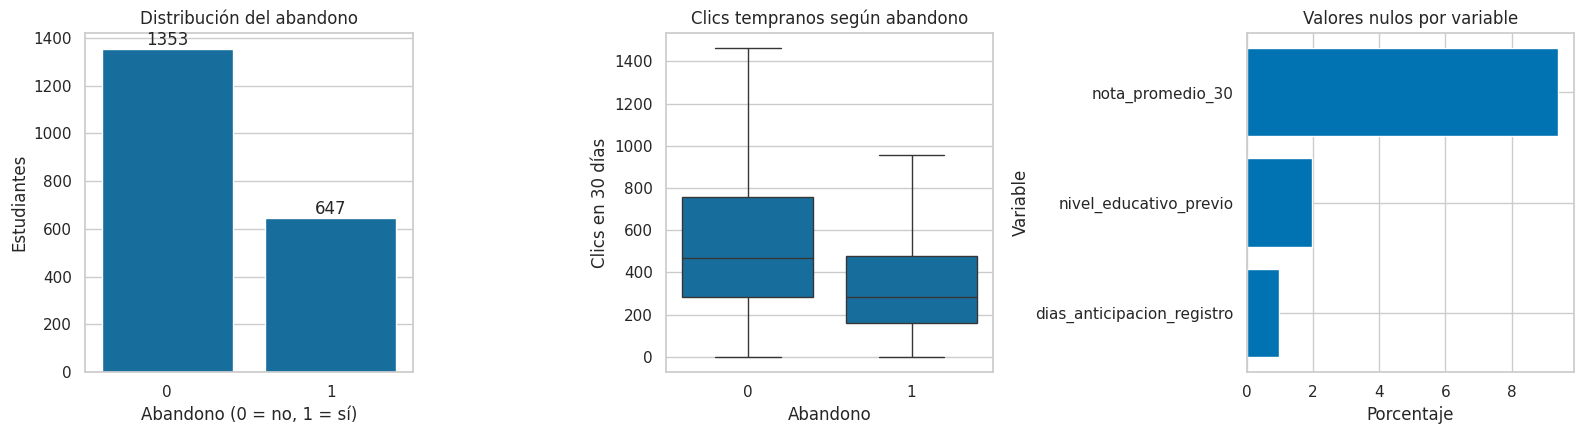

In [ ]:
distribucion_objetivo = (
    datos['abandono'].value_counts().sort_index().rename_axis('abandono')
    .reset_index(name='cantidad')
)
distribucion_objetivo['porcentaje'] = (
    distribucion_objetivo['cantidad'] / len(datos) * 100
).round(2)
display(distribucion_objetivo)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.countplot(data=datos, x='abandono', ax=axes[0])
axes[0].set(title='Distribución del abandono', xlabel='Abandono (0 = no, 1 = sí)', ylabel='Estudiantes')
for container in axes[0].containers:
    axes[0].bar_label(container)

sns.boxplot(data=datos, x='abandono', y='clicks_30_dias', showfliers=False, ax=axes[1])
axes[1].set(title='Clics tempranos según abandono', xlabel='Abandono', ylabel='Clics en 30 días')

nulos_grafico = calidad_antes.query('porcentaje_nulos > 0').sort_values('porcentaje_nulos')
axes[2].barh(nulos_grafico.index, nulos_grafico['porcentaje_nulos'])
axes[2].set(title='Valores nulos por variable', xlabel='Porcentaje', ylabel='Variable')

plt.tight_layout()
plt.savefig(RUTA_FIGURAS / '01_exploracion_principal.png', dpi=160, bbox_inches='tight')
plt.show()

NUMERO_VISUALIZACIONES = 3

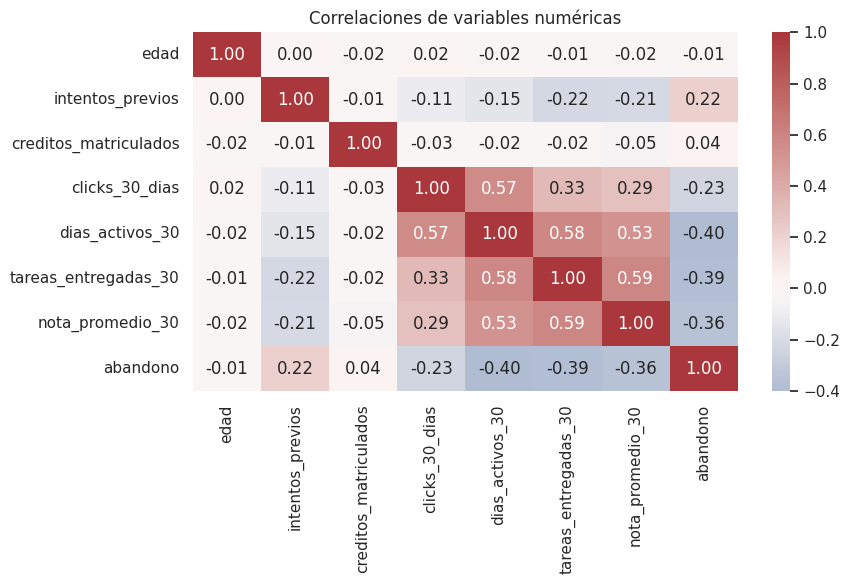

In [ ]:
columnas_correlacion = [
    'edad', 'intentos_previos', 'creditos_matriculados', 'clicks_30_dias',
    'dias_activos_30', 'tareas_entregadas_30', 'nota_promedio_30', 'abandono',
]
correlaciones = datos[columnas_correlacion].corr(numeric_only=True)

plt.figure(figsize=(9, 6))
sns.heatmap(correlaciones, annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Correlaciones de variables numéricas')
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / '02_correlaciones.png', dpi=160, bbox_inches='tight')
plt.show()

NUMERO_VISUALIZACIONES += 1

## 3. Valores atípicos y transformaciones

Los valores atípicos se identifican mediante el rango intercuartílico. No se eliminan automáticamente porque una actividad elevada puede representar un comportamiento real. Su influencia se reduce mediante transformación logarítmica y escalado robusto.

Se aplica la transformación logarítmica natural

\[
x' = \ln(1+x)
\]

a los clics. El `+1` conserva los valores iguales a cero y la transformación reduce la asimetría positiva. No es una normalización: el escalado posterior se realiza con `RobustScaler` dentro del pipeline.

In [ ]:
variables_outliers = [
    'edad', 'creditos_matriculados', 'dias_anticipacion_registro',
    'clicks_30_dias', 'dias_activos_30', 'tareas_entregadas_30',
    'nota_promedio_30',
]

filas_outliers = []
for columna in variables_outliers:
    serie = datos[columna].dropna()
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    mascara = (serie < limite_inferior) | (serie > limite_superior)
    cantidad = int(mascara.sum())
    filas_outliers.append({
        'variable': columna,
        'limite_inferior': round(limite_inferior, 3),
        'limite_superior': round(limite_superior, 3),
        'cantidad_atipicos': cantidad,
        'porcentaje_atipicos': round(cantidad / len(serie) * 100, 2),
        'tratamiento': 'Conservar; usar log y/o escalado robusto',
    })

tabla_outliers = pd.DataFrame(filas_outliers).sort_values(
    'porcentaje_atipicos', ascending=False
)
display(tabla_outliers)

,variable,limite_inferior,limite_superior,cantidad_atipicos,porcentaje_atipicos,tratamiento
1,creditos_matriculados,-15.000,105.000,108,5.40,Conservar; usar log y/o escalado robusto
3,clicks_30_dias,-412.875,1304.125,79,3.95,Conservar; usar log y/o escalado robusto
5,tareas_entregadas_30,-1.000,7.000,14,0.70,Conservar; usar log y/o escalado robusto
2,dias_anticipacion_registro,-22.000,90.000,11,0.56,Conservar; usar log y/o escalado robusto
0,edad,6.500,50.500,7,0.35,Conservar; usar log y/o escalado robusto
6,nota_promedio_30,26.473,120.904,1,0.06,Conservar; usar log y/o escalado robusto
4,dias_activos_30,-7.000,33.000,0,0.00,Conservar; usar log y/o escalado robusto


# Fase 3. Ingeniería de variables

Se generan cuatro variables derivadas. Las divisiones controlan explícitamente los denominadores iguales a cero.

In [ ]:
datos['clicks_por_dia_activo'] = np.divide(
    datos['clicks_30_dias'],
    datos['dias_activos_30'],
    out=np.zeros(len(datos), dtype=float),
    where=datos['dias_activos_30'].gt(0),
)
datos['tasa_entrega_30'] = (
    datos['tareas_entregadas_30'] / datos['tareas_asignadas_30']
)
datos['tasa_actividad_30'] = datos['dias_activos_30'] / VENTANA_DIAS
datos['log_clicks_30'] = np.log1p(datos['clicks_30_dias'])
datos['sin_nota_30'] = datos['nota_promedio_30'].isna().astype('int8')

variables_derivadas = [
    'clicks_por_dia_activo', 'tasa_entrega_30', 'tasa_actividad_30',
    'log_clicks_30', 'sin_nota_30',
]

comparacion_asimetria = pd.DataFrame({
    'variable': ['clicks_30_dias', 'log_clicks_30'],
    'asimetria': [datos['clicks_30_dias'].skew(), datos['log_clicks_30'].skew()],
}).round(3)

display(datos[['id_estudiante'] + variables_derivadas].head())
display(comparacion_asimetria)
print('Variables derivadas creadas:', len(variables_derivadas))

,id_estudiante,clicks_por_dia_activo,tasa_entrega_30,tasa_actividad_30,log_clicks_30,sin_nota_30
0,1,5.909091,0.285714,0.366667,4.189655,0
1,2,17.944444,0.857143,0.600000,5.780744,0
2,3,8.466667,0.800000,0.500000,4.852030,0
3,4,43.666667,0.400000,0.200000,5.572154,0
4,5,41.526316,0.750000,0.633333,6.672033,0


,variable,asimetria
0,clicks_30_dias,5.156
1,log_clicks_30,-1.010


Variables derivadas creadas: 5


# Fase 4. PCA y clustering descriptivo

K-Means identifica perfiles de participación; no predice el abandono. La variable objetivo y el identificador quedan excluidos. Los valores faltantes de nota se imputan con la mediana y `sin_nota_30` conserva la información de ausencia, evitando interpretar una nota imputada como observada.

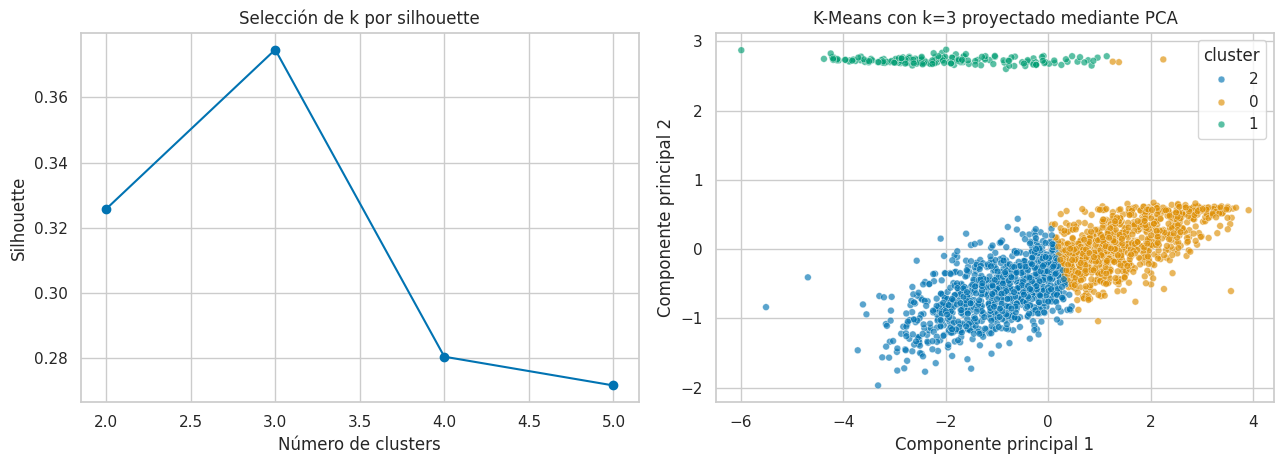

,k,silhouette,inercia
0,2,0.3257,6350.5202
1,3,0.3747,4440.6005
2,4,0.2803,3696.8238
3,5,0.2715,3257.0813


,k,silhouette,davies_bouldin
0,3,0.3747,0.965


,cluster,estudiantes,dias_activos_promedio,tasa_entrega_promedio,nota_promedio,porcentaje_sin_nota,tasa_abandono_observada
0,0,867,18.646,0.709,85.027,0.003,0.114
1,1,185,8.746,0.179,NaN,1.000,0.578
2,2,948,9.453,0.358,62.480,0.000,0.465


Varianza explicada por dos componentes: 0.7389


In [ ]:
VARIABLES_CLUSTER = [
    'log_clicks_30', 'tasa_actividad_30', 'tasa_entrega_30',
    'nota_promedio_30', 'sin_nota_30',
]

preprocesamiento_cluster = Pipeline([
    ('imputacion', SimpleImputer(strategy='median')),
    ('escalado', StandardScaler()),
])
X_cluster = preprocesamiento_cluster.fit_transform(datos[VARIABLES_CLUSTER])

resultados_k = []
for k in range(2, 6):
    candidato = KMeans(n_clusters=k, n_init=20, random_state=SEMILLA)
    etiquetas = candidato.fit_predict(X_cluster)
    resultados_k.append({
        'k': k,
        'silhouette': silhouette_score(X_cluster, etiquetas),
        'inercia': candidato.inertia_,
    })

evaluacion_k = pd.DataFrame(resultados_k)
MEJOR_K = int(evaluacion_k.loc[evaluacion_k['silhouette'].idxmax(), 'k'])
kmeans = KMeans(n_clusters=MEJOR_K, n_init=30, random_state=SEMILLA)
datos['cluster'] = kmeans.fit_predict(X_cluster)

metricas_cluster = pd.DataFrame([{
    'k': MEJOR_K,
    'silhouette': silhouette_score(X_cluster, datos['cluster']),
    'davies_bouldin': davies_bouldin_score(X_cluster, datos['cluster']),
}])

pca = PCA(n_components=2, random_state=SEMILLA)
coordenadas = pca.fit_transform(X_cluster)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(evaluacion_k['k'], evaluacion_k['silhouette'], marker='o')
axes[0].set(title='Selección de k por silhouette', xlabel='Número de clusters', ylabel='Silhouette')
sns.scatterplot(
    x=coordenadas[:, 0], y=coordenadas[:, 1],
    hue=datos['cluster'].astype(str), alpha=0.65, s=24, ax=axes[1],
)
axes[1].set(
    title=f'K-Means con k={MEJOR_K} proyectado mediante PCA',
    xlabel='Componente principal 1', ylabel='Componente principal 2',
)
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / '03_clustering_pca.png', dpi=160, bbox_inches='tight')
plt.show()

NUMERO_VISUALIZACIONES += 2

perfil_cluster = datos.groupby('cluster', as_index=False).agg(
    estudiantes=('id_estudiante', 'size'),
    dias_activos_promedio=('dias_activos_30', 'mean'),
    tasa_entrega_promedio=('tasa_entrega_30', 'mean'),
    nota_promedio=('nota_promedio_30', 'mean'),
    porcentaje_sin_nota=('sin_nota_30', 'mean'),
    tasa_abandono_observada=('abandono', 'mean'),
)

display(evaluacion_k.round(4))
display(metricas_cluster.round(4))
display(perfil_cluster.round(3))
print('Varianza explicada por dos componentes:', round(pca.explained_variance_ratio_.sum(), 4))

# Fase 5. Modelado predictivo

- División externa: 80 % entrenamiento y 20 % prueba, estratificada.
- Nulos numéricos: mediana más indicador de ausencia.
- Variables numéricas: `RobustScaler`.
- Variables categóricas: imputación por moda y `OneHotEncoder`.
- Validación: `StratifiedKFold` con cinco particiones solo sobre entrenamiento.
- Selección: mayor F1 promedio; ROC-AUC se utiliza para desempatar.
- El conjunto de prueba se consulta una sola vez después de seleccionar el algoritmo.

In [ ]:
VARIABLES_CATEGORICAS = ['modalidad', 'nivel_educativo_previo']
VARIABLES_NUMERICAS = [
    'edad', 'intentos_previos', 'creditos_matriculados',
    'dias_anticipacion_registro', 'dias_activos_30',
    'tareas_asignadas_30', 'tareas_entregadas_30', 'nota_promedio_30',
    'solicito_soporte', 'clicks_por_dia_activo', 'tasa_entrega_30',
    'tasa_actividad_30', 'log_clicks_30', 'sin_nota_30',
]
VARIABLES_MODELO = VARIABLES_CATEGORICAS + VARIABLES_NUMERICAS

X = datos[VARIABLES_MODELO].copy()
y = datos['abandono'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEMILLA
)

def crear_preprocesador():
    numerico = Pipeline([
        ('imputacion', SimpleImputer(strategy='median', add_indicator=True)),
        ('escalado', RobustScaler()),
    ])
    categorico = Pipeline([
        ('imputacion', SimpleImputer(strategy='most_frequent')),
        ('one_hot', OneHotEncoder(handle_unknown='ignore')),
    ])
    return ColumnTransformer([
        ('numericas', numerico, VARIABLES_NUMERICAS),
        ('categoricas', categorico, VARIABLES_CATEGORICAS),
    ])

def crear_pipeline(modelo):
    return Pipeline([
        ('preprocesamiento', crear_preprocesador()),
        ('modelo', modelo),
    ])

resumen_particion = pd.DataFrame([
    ['Entrenamiento', len(X_train), y_train.mean()],
    ['Prueba', len(X_test), y_test.mean()],
], columns=['conjunto', 'registros', 'proporcion_abandono'])
display(resumen_particion.round(4))

,conjunto,registros,proporcion_abandono
0,Entrenamiento,1600,0.3238
1,Prueba,400,0.3225


In [ ]:
MODELOS = {
    'Regresión logística': crear_pipeline(LogisticRegression(
        C=1.0, class_weight='balanced', solver='liblinear',
        max_iter=2000, random_state=SEMILLA,
    )),
    'Árbol de decisión': crear_pipeline(DecisionTreeClassifier(
        max_depth=6, min_samples_split=30, min_samples_leaf=20,
        class_weight='balanced', random_state=SEMILLA,
    )),
    'Bosque aleatorio': crear_pipeline(RandomForestClassifier(
        n_estimators=250, max_depth=10, min_samples_leaf=5,
        max_features='sqrt', class_weight='balanced_subsample',
        n_jobs=-1, random_state=SEMILLA,
    )),
}

tabla_parametros = pd.DataFrame([
    ['Regresión logística', 'C=1.0; balanced; liblinear; max_iter=2000'],
    ['Árbol de decisión', 'max_depth=6; min_samples_split=30; min_samples_leaf=20; balanced'],
    ['Bosque aleatorio', '250 árboles; max_depth=10; min_samples_leaf=5; sqrt; balanced_subsample'],
], columns=['modelo', 'parametros_principales'])

display(tabla_parametros)

,modelo,parametros_principales
0,Regresión logística,C=1.0; balanced; liblinear; max_iter=2000
1,Árbol de decisión,max_depth=6; min_samples_split=30; min_samples...
2,Bosque aleatorio,250 árboles; max_depth=10; min_samples_leaf=5;...


,modelo,accuracy_media,accuracy_std,precision_media,precision_std,recall_media,recall_std,f1_media,f1_std,roc_auc_media,roc_auc_std
0,Regresión logística,0.7175,0.0233,0.5474,0.0271,0.7414,0.0417,0.6295,0.0294,0.8047,0.0221
1,Bosque aleatorio,0.7375,0.0199,0.5853,0.0284,0.6526,0.0303,0.6169,0.0258,0.7943,0.0239
2,Árbol de decisión,0.6950,0.0315,0.5244,0.0398,0.6874,0.0636,0.5932,0.0342,0.7572,0.0195


Modelo seleccionado por validación cruzada: Regresión logística


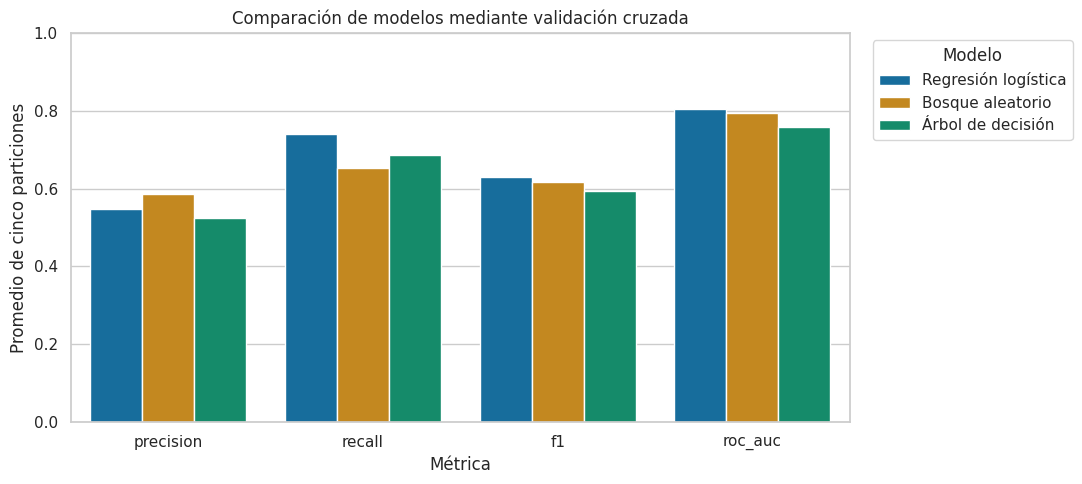

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
}

filas_resultados = []
for nombre, pipeline in MODELOS.items():
    resultados = cross_validate(
        pipeline, X_train, y_train, cv=cv, scoring=scoring,
        n_jobs=-1, return_train_score=False,
    )
    fila = {'modelo': nombre}
    for metrica in scoring:
        valores = resultados[f'test_{metrica}']
        fila[f'{metrica}_media'] = valores.mean()
        fila[f'{metrica}_std'] = valores.std(ddof=1)
    filas_resultados.append(fila)

comparacion_modelos = pd.DataFrame(filas_resultados).sort_values(
    ['f1_media', 'roc_auc_media'], ascending=False
).reset_index(drop=True)
MEJOR_MODELO_NOMBRE = comparacion_modelos.iloc[0]['modelo']

display(comparacion_modelos.round(4))
print('Modelo seleccionado por validación cruzada:', MEJOR_MODELO_NOMBRE)

metricas_grafico = ['precision_media', 'recall_media', 'f1_media', 'roc_auc_media']
comparacion_larga = comparacion_modelos.melt(
    id_vars='modelo', value_vars=metricas_grafico,
    var_name='metrica', value_name='valor',
)
comparacion_larga['metrica'] = comparacion_larga['metrica'].str.replace('_media', '')

plt.figure(figsize=(11, 5))
sns.barplot(data=comparacion_larga, x='metrica', y='valor', hue='modelo')
plt.ylim(0, 1)
plt.title('Comparación de modelos mediante validación cruzada')
plt.xlabel('Métrica')
plt.ylabel('Promedio de cinco particiones')
plt.legend(title='Modelo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / '04_comparacion_modelos.png', dpi=160, bbox_inches='tight')
plt.show()

NUMERO_VISUALIZACIONES += 1

## 4. Evaluación final sobre datos no vistos

Para una alerta temprana, `recall` indica cuántos abandonos reales se detectan y `precision` indica cuántas alertas emitidas son correctas. F1 equilibra ambos criterios y ROC-AUC mide la capacidad de discriminación en diferentes umbrales.

,modelo,accuracy,precision,recall,f1,roc_auc
0,Regresión logística,0.695,0.5202,0.6977,0.596,0.7724


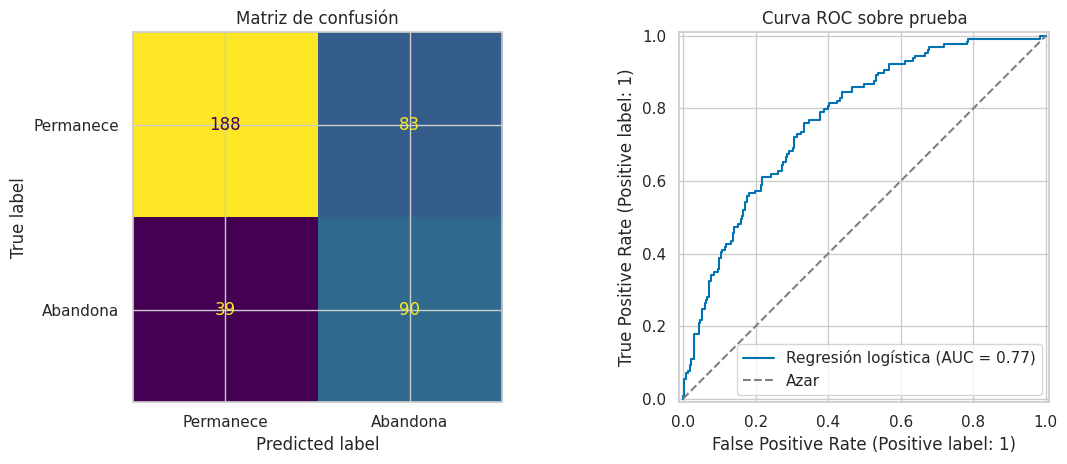


INTERPRETACIÓN DEL MODELO FINAL
- Recall = 69.77%: detecta esta proporción de abandonos reales.
- Precision = 52.02%: esta proporción de alertas es correcta.
- F1 = 0.5960: equilibrio entre omisiones y falsas alarmas.
- ROC-AUC = 0.7724: capacidad global de discriminación.
- Falsos negativos: 39; son abandonos no detectados.
- Falsos positivos: 83; son alertas preventivas innecesarias.
- Los resultados corresponden a datos simulados y no demuestran validez institucional real.


In [ ]:
modelo_evaluacion = clone(MODELOS[MEJOR_MODELO_NOMBRE])
modelo_evaluacion.fit(X_train, y_train)

y_pred = modelo_evaluacion.predict(X_test)
y_prob = modelo_evaluacion.predict_proba(X_test)[:, 1]

metricas_prueba = pd.DataFrame([{
    'modelo': MEJOR_MODELO_NOMBRE,
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_prob),
}])
matriz = confusion_matrix(y_test, y_pred)

display(metricas_prueba.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=['Permanece', 'Abandona'],
).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Matriz de confusión')

RocCurveDisplay.from_predictions(y_test, y_prob, name=MEJOR_MODELO_NOMBRE, ax=axes[1])
axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Azar')
axes[1].set_title('Curva ROC sobre prueba')
axes[1].legend()
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / '05_evaluacion_final.png', dpi=160, bbox_inches='tight')
plt.show()

NUMERO_VISUALIZACIONES += 2

tn, fp, fn, tp = matriz.ravel()
resultado = metricas_prueba.iloc[0]
print('\nINTERPRETACIÓN DEL MODELO FINAL')
print(f"- Recall = {resultado['recall']:.2%}: detecta esta proporción de abandonos reales.")
print(f"- Precision = {resultado['precision']:.2%}: esta proporción de alertas es correcta.")
print(f"- F1 = {resultado['f1']:.4f}: equilibrio entre omisiones y falsas alarmas.")
print(f"- ROC-AUC = {resultado['roc_auc']:.4f}: capacidad global de discriminación.")
print(f'- Falsos negativos: {fn}; son abandonos no detectados.')
print(f'- Falsos positivos: {fp}; son alertas preventivas innecesarias.')
print('- Los resultados corresponden a datos simulados y no demuestran validez institucional real.')

,variable,importancia_media_roc_auc,desviacion
12,tasa_entrega_30,0.0532,0.0154
3,intentos_previos,0.0176,0.0048
13,tasa_actividad_30,0.0164,0.0041
6,dias_activos_30,0.0164,0.0041
8,tareas_entregadas_30,0.0104,0.0064
9,nota_promedio_30,0.0089,0.0040
10,solicito_soporte,0.0036,0.0025
7,tareas_asignadas_30,0.0008,0.0049
4,creditos_matriculados,0.0007,0.0013
2,edad,0.0001,0.0001


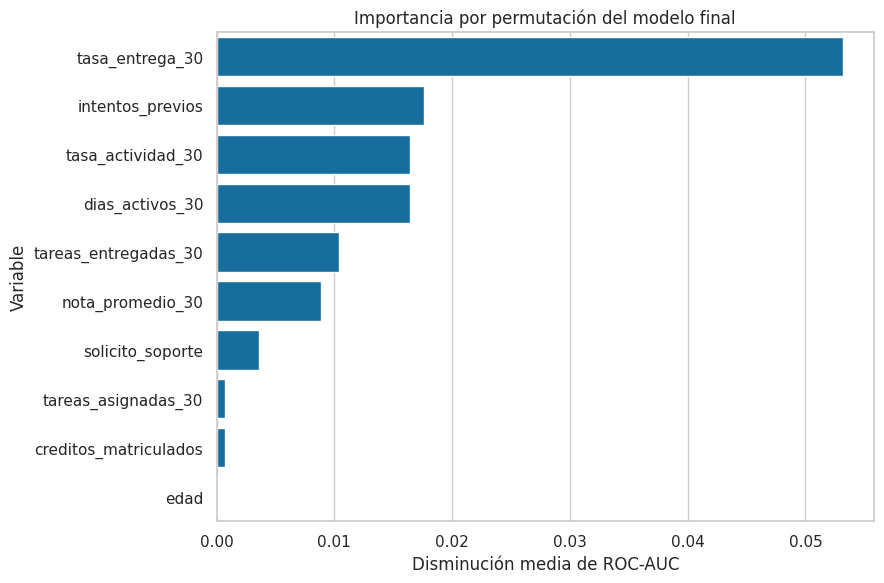

Las importancias muestran asociación predictiva, no causalidad.


In [ ]:
importancia = permutation_importance(
    modelo_evaluacion, X_test, y_test,
    scoring='roc_auc', n_repeats=10, random_state=SEMILLA, n_jobs=-1,
)
importancia_variables = pd.DataFrame({
    'variable': VARIABLES_MODELO,
    'importancia_media_roc_auc': importancia.importances_mean,
    'desviacion': importancia.importances_std,
}).sort_values('importancia_media_roc_auc', ascending=False)

display(importancia_variables.round(4))

plt.figure(figsize=(9, 6))
sns.barplot(
    data=importancia_variables.head(10),
    x='importancia_media_roc_auc', y='variable',
)
plt.title('Importancia por permutación del modelo final')
plt.xlabel('Disminución media de ROC-AUC')
plt.ylabel('Variable')
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / '06_importancia_variables.png', dpi=160, bbox_inches='tight')
plt.show()

NUMERO_VISUALIZACIONES += 1
print('Las importancias muestran asociación predictiva, no causalidad.')

# Fase 6. Entrenamiento y exportación

Después de conservar las métricas obtenidas sobre prueba, el algoritmo elegido se vuelve a entrenar con los 2.000 registros únicos. El archivo `joblib` contiene el preprocesamiento y el clasificador en una sola tubería, evitando que la futura API replique manualmente la imputación, codificación o escala.

In [ ]:
modelo_despliegue = clone(MODELOS[MEJOR_MODELO_NOMBRE])
modelo_despliegue.fit(X, y)

opciones_categoricas = {
    columna: sorted(datos[columna].dropna().astype(str).unique().tolist())
    for columna in VARIABLES_CATEGORICAS
}
valores_referencia = {
    columna: float(datos[columna].median())
    for columna in VARIABLES_NUMERICAS
    if not pd.isna(datos[columna].median())
}

metadatos = {
    'nombre_modelo': MEJOR_MODELO_NOMBRE,
    'tipo_base': 'simulada reproducible inspirada en OULAD',
    'semilla': SEMILLA,
    'ventana_observacion_dias': VENTANA_DIAS,
    'definicion_objetivo': 'abandono posterior al día 30',
    'umbral_clasificacion': 0.50,
    'variables_modelo': VARIABLES_MODELO,
    'variables_categoricas': VARIABLES_CATEGORICAS,
    'variables_numericas': VARIABLES_NUMERICAS,
    'opciones_categoricas': opciones_categoricas,
    'valores_referencia': valores_referencia,
    'metricas_prueba': {
        clave: (valor.item() if hasattr(valor, 'item') else valor)
        for clave, valor in metricas_prueba.iloc[0].to_dict().items()
    },
    'limitacion': 'Modelo académico entrenado con datos simulados; requiere validación externa antes de uso real.',
}

paquete_modelo = {
    'model': modelo_despliegue,
    'feature_columns': VARIABLES_MODELO,
    'metadata': metadatos,
}

RUTA_MODELO = RUTA_EXPORTACION / 'modelo_alerta_estudiantil.joblib'
RUTA_METADATA = RUTA_EXPORTACION / 'metadata_modelo.json'
RUTA_REQUIREMENTS = RUTA_EXPORTACION / 'requirements_modelo.txt'
RUTA_CSV_LIMPIO = RUTA_EXPORTACION / 'base_estudiantes_simulada_limpia.csv'

joblib.dump(paquete_modelo, RUTA_MODELO, compress=3)
RUTA_METADATA.write_text(
    json.dumps(metadatos, ensure_ascii=False, indent=2), encoding='utf-8'
)
versiones = {
    paquete: package_metadata.version(paquete)
    for paquete in ['numpy', 'pandas', 'scikit-learn', 'joblib']
}
RUTA_REQUIREMENTS.write_text(
    ''.join(f'{paquete}=={version}\n' for paquete, version in versiones.items()),
    encoding='utf-8',
)
datos.drop(columns=['cluster']).to_csv(RUTA_CSV_LIMPIO, index=False)

# Prueba de portabilidad: se recarga el objeto y se ejecuta una predicción.
paquete_recargado = joblib.load(RUTA_MODELO)
muestra_api = X.iloc[[0]].copy()
probabilidad_prueba = float(paquete_recargado['model'].predict_proba(muestra_api)[0, 1])
assert 0 <= probabilidad_prueba <= 1
assert paquete_recargado['feature_columns'] == VARIABLES_MODELO

RUTA_ZIP = RUTA_TRABAJO / 'paquete_modelo_alerta_estudiantil.zip'
with zipfile.ZipFile(RUTA_ZIP, 'w', compression=zipfile.ZIP_DEFLATED) as archivo_zip:
    for archivo in [RUTA_MODELO, RUTA_METADATA, RUTA_REQUIREMENTS]:
        archivo_zip.write(archivo, arcname=archivo.name)

archivos_exportados = pd.DataFrame([
    {'archivo': archivo.name, 'tamano_kb': round(archivo.stat().st_size / 1024, 2)}
    for archivo in [RUTA_MODELO, RUTA_METADATA, RUTA_REQUIREMENTS, RUTA_CSV_LIMPIO, RUTA_ZIP]
])
display(archivos_exportados)
print('Modelo recargado correctamente.')
print('Probabilidad de prueba:', round(probabilidad_prueba, 4))
print('Paquete listo para la futura API:', RUTA_ZIP)

try:
    from google.colab import files
    files.download(str(RUTA_ZIP))
except ImportError:
    print('Descarga automática disponible al ejecutar esta celda en Google Colab.')

,archivo,tamano_kb
0,modelo_alerta_estudiantil.joblib,2.94
1,metadata_modelo.json,2.11
2,requirements_modelo.txt,0.06
3,base_estudiantes_simulada_limpia.csv,247.08
4,paquete_modelo_alerta_estudiantil.zip,4.12


Modelo recargado correctamente.
Probabilidad de prueba: 0.6967
Paquete listo para la futura API: /content/mineria_datos_modelo_final/paquete_modelo_alerta_estudiantil.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 5. Verificación técnica del Colab

Esta comprobación valida únicamente la etapa actual. No afirma que el PDF, GitHub, la API o el artículo IEEE estén terminados.

In [ ]:
verificacion_colab = pd.DataFrame([
    ['Mínimo 1.000 registros', len(datos) >= 1_000, len(datos)],
    ['Mínimo 5 variables', datos.shape[1] >= 5, datos.shape[1]],
    ['Nulos con porcentaje', 'porcentaje_nulos' in calidad_antes.columns, len(calidad_antes)],
    ['Duplicados cuantificados', duplicados_antes >= 0, duplicados_antes],
    ['Duplicados eliminados', duplicados_despues == 0, duplicados_despues],
    ['Atípicos documentados', not tabla_outliers.empty, len(tabla_outliers)],
    ['Al menos 3 visualizaciones', NUMERO_VISUALIZACIONES >= 3, NUMERO_VISUALIZACIONES],
    ['Al menos 2 variables derivadas', len(variables_derivadas) >= 2, len(variables_derivadas)],
    ['Tres modelos predictivos', len(MODELOS) >= 3, len(MODELOS)],
    ['División 80/20', abs(len(X_test) / len(X) - 0.20) < 0.001, len(X_test) / len(X)],
    ['Validación cruzada de 5 folds', cv.get_n_splits() == 5, cv.get_n_splits()],
    ['Al menos 2 métricas', len(scoring) >= 2, len(scoring)],
    ['Tabla comparativa', len(comparacion_modelos) == len(MODELOS), len(comparacion_modelos)],
    ['Modelo exportado', RUTA_MODELO.is_file(), RUTA_MODELO.name],
    ['Portabilidad comprobada', 0 <= probabilidad_prueba <= 1, probabilidad_prueba],
], columns=['comprobacion', 'cumple', 'evidencia'])

display(verificacion_colab)
assert verificacion_colab['cumple'].all(), 'Existe una comprobación técnica pendiente.'
print('COLAB COMPLETO: todas las comprobaciones técnicas fueron superadas.')

,comprobacion,cumple,evidencia
0,Mínimo 1.000 registros,True,2000
1,Mínimo 5 variables,True,20
2,Nulos con porcentaje,True,14
3,Duplicados cuantificados,True,20
4,Duplicados eliminados,True,0
5,Atípicos documentados,True,7
6,Al menos 3 visualizaciones,True,10
7,Al menos 2 variables derivadas,True,5
8,Tres modelos predictivos,True,3
9,División 80/20,True,0.2


COLAB COMPLETO: todas las comprobaciones técnicas fueron superadas.


# Conclusión de esta etapa

El cuaderno construye una base simulada transparente, documenta su calidad, realiza limpieza y transformación, identifica perfiles descriptivos y compara tres modelos predictivos mediante validación cruzada. El algoritmo final se evalúa sobre datos no vistos y se exporta junto con todo el preprocesamiento necesario.

El resultado constituye un prototipo académico reproducible. Debido a que los datos son simulados, sus métricas demuestran el funcionamiento del procedimiento, pero no garantizan desempeño en una institución real. La siguiente etapa será implementar una API que cargue `modelo_alerta_estudiantil.joblib` y valide exactamente las variables indicadas en `metadata_modelo.json`.

## Referencias

Kuzilek, J., Hlosta, M., & Zdrahal, Z. (2017). Open University Learning Analytics dataset. *Scientific Data, 4*, Article 170171. https://doi.org/10.1038/sdata.2017.171

Villar, A., & de Andrade, C. R. V. (2024). Supervised machine learning algorithms for predicting student dropout and academic success: A comparative study. *Discover Artificial Intelligence, 4*, Article 2. https://doi.org/10.1007/s44163-023-00079-z